# Comparison of Average Forecasting and STL Forecasting

This analysis compares the forecasting accuracy of two forecasting methods:

1. Average Forecasting
2. STL Forecasting

The forecasted call volumes are compared with the actual call volumes recorded during 2024.

The comparison is performed using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Weighted Absolute Percentage Error (WAPE)
- Forecast Bias
- Diebold-Mariano test for predictive accuracy

The actual call records are first aggregated into 30-minute intervals so that they correspond with the forecast intervals.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [17]:
from google.colab import files
uploaded = files.upload()

Saving average_erlang_forecast_2024.csv to average_erlang_forecast_2024.csv
Saving stl_erlang_forecast_2024.csv to stl_erlang_forecast_2024.csv
Saving cdr_2024.csv to cdr_2024.csv


## Load the Data

The Average and STL forecast datasets contain forecasted call volumes for each 30-minute interval.

The CDR dataset contains individual call records. Therefore, the CDR data must later be aggregated into 30-minute intervals before it can be compared with the forecasts.

In [18]:
average = pd.read_csv(
    "average_erlang_forecast_2024.csv"
)

stl = pd.read_csv(
    "stl_erlang_forecast_2024.csv"
)

cdr = pd.read_csv(
    "cdr_2024.csv",
    header=None,
    names=[
        "agent",
        "extension",
        "timestamp",
        "duration",
        "status",
        "call_id",
        "phone"
    ]
)

Before performing the analysis, the structure of each dataset is examined to confirm that the files were loaded correctly.

In [19]:
print("Average Forecast:")
display(average.head())

print("\nSTL Forecast:")
display(stl.head())

print("\nActual CDR:")
display(cdr.head())

Average Forecast:


,interval_start,date,day_of_year,month,day,weekday,weekday_name,hour,minute,call_volume,aht_seconds,traffic_erlangs,raw_agents,scheduled_agents,service_level_percent,probability_waiting_percent,occupancy_percent,asa_seconds
0,2024-01-01T00:00:00,2024-01-01,1,1,1,0,Monday,0,0,0,283.07,0.0,0,0,100.0,0.0,0.0,0.0
1,2024-01-01T00:30:00,2024-01-01,1,1,1,0,Monday,0,30,0,283.07,0.0,0,0,100.0,0.0,0.0,0.0
2,2024-01-01T01:00:00,2024-01-01,1,1,1,0,Monday,1,0,0,283.07,0.0,0,0,100.0,0.0,0.0,0.0
3,2024-01-01T01:30:00,2024-01-01,1,1,1,0,Monday,1,30,0,283.07,0.0,0,0,100.0,0.0,0.0,0.0
4,2024-01-01T02:00:00,2024-01-01,1,1,1,0,Monday,2,0,0,1012.00,0.0,0,0,100.0,0.0,0.0,0.0



STL Forecast:


,interval_start,date,day_of_year,month,day,weekday,weekday_name,hour,minute,call_volume,aht_seconds,traffic_erlangs,raw_agents,scheduled_agents,service_level_percent,probability_waiting_percent,occupancy_percent,asa_seconds
0,2024-01-01T00:00:00,2024-01-01,1,1,1,0,Monday,0,0,7,218.25,0.8488,3,5,95.04,6.04,28.29,6.13
1,2024-01-01T00:30:00,2024-01-01,1,1,1,0,Monday,0,30,2,260.24,0.2892,2,3,96.80,3.65,14.46,5.56
2,2024-01-01T01:00:00,2024-01-01,1,1,1,0,Monday,1,0,1,227.60,0.1264,1,2,88.29,12.64,12.64,32.94
3,2024-01-01T01:30:00,2024-01-01,1,1,1,0,Monday,1,30,2,259.42,0.2882,2,3,96.82,3.63,14.41,5.50
4,2024-01-01T02:00:00,2024-01-01,1,1,1,0,Monday,2,0,0,219.08,0.0000,0,0,100.00,0.00,0.00,0.00



Actual CDR:


,agent,extension,timestamp,duration,status,call_id,phone
0,1004.0,2024,2024-Jan-01 12:28:48 AM,00:02:06,Answered,1.704049e+09,0756562582
1,1002.0,2007,2024-Jan-01 12:31:52 AM,00:04:31,Answered,1.704049e+09,0775946249
2,1001.0,2016,2024-Jan-01 12:56:12 AM,00:02:26,Answered,1.704051e+09,0750224822
3,1005.0,2027,2024-Jan-01 01:17:14 AM,00:04:17,Answered,1.704052e+09,0773343115
4,1002.0,2015,2024-Jan-01 01:33:00 AM,00:02:30,Answered,1.704053e+09,0911598210


In [20]:
print("Average shape:", average.shape)
print("STL shape:", stl.shape)
print("CDR shape:", cdr.shape)

Average shape: (17520, 18)
STL shape: (17520, 18)
CDR shape: (240375, 7)


## Data Preparation

The timestamps in the forecast datasets are converted to datetime format.

Only the interval timestamp and forecasted call volume are required for the accuracy comparison.

The forecast columns are renamed so that the two forecasting methods can be clearly identified after merging.

In [21]:
average["interval_start"] = pd.to_datetime(
    average["interval_start"]
)

stl["interval_start"] = pd.to_datetime(
    stl["interval_start"]
)

average = average[
    ["interval_start", "call_volume"]
].rename(
    columns={
        "call_volume": "average_forecast"
    }
)

stl = stl[
    ["interval_start", "call_volume"]
].rename(
    columns={
        "call_volume": "stl_forecast"
    }
)

In [22]:
display(average.head())
display(stl.head())

,interval_start,average_forecast
0,2024-01-01 00:00:00,0
1,2024-01-01 00:30:00,0
2,2024-01-01 01:00:00,0
3,2024-01-01 01:30:00,0
4,2024-01-01 02:00:00,0


,interval_start,stl_forecast
0,2024-01-01 00:00:00,7
1,2024-01-01 00:30:00,2
2,2024-01-01 01:00:00,1
3,2024-01-01 01:30:00,2
4,2024-01-01 02:00:00,0


## Aggregation of Actual Call Volume

The actual CDR dataset contains one record for each call, whereas the forecasting datasets contain call volume for 30-minute intervals.

To make the datasets comparable, each actual call is assigned to its corresponding 30-minute interval.

The number of calls occurring within each interval is then calculated. This produces the actual call volume for each 30-minute period.

In [23]:
cdr["timestamp"] = pd.to_datetime(
    cdr["timestamp"],
    format="%Y-%b-%d %I:%M:%S %p",
    errors="coerce"
)

cdr = cdr.dropna(
    subset=["timestamp"]
)

cdr["interval_start"] = (
    cdr["timestamp"].dt.floor("30min")
)

actual = (
    cdr.groupby("interval_start")
       .size()
       .reset_index(name="actual")
)

display(actual.head(10))

,interval_start,actual
0,2024-01-01 00:00:00,1
1,2024-01-01 00:30:00,2
2,2024-01-01 01:00:00,1
3,2024-01-01 01:30:00,1
4,2024-01-01 02:00:00,1
5,2024-01-01 04:00:00,1
6,2024-01-01 05:30:00,3
7,2024-01-01 06:00:00,1
8,2024-01-01 06:30:00,1
9,2024-01-01 07:00:00,4


### Verification of Actual Call Volume

The aggregated dataset is inspected to confirm that each observation now represents the number of calls received within a 30-minute interval.

In [24]:
print(
    "Number of actual intervals:",
    len(actual)
)

print(
    "Total number of actual calls:",
    actual["actual"].sum()
)

display(actual.head())

Number of actual intervals: 15450
Total number of actual calls: 240145


,interval_start,actual
0,2024-01-01 00:00:00,1
1,2024-01-01 00:30:00,2
2,2024-01-01 01:00:00,1
3,2024-01-01 01:30:00,1
4,2024-01-01 02:00:00,1


## Merge Actual and Forecast Data

The Average forecast, STL forecast and actual call-volume datasets are merged using the 30-minute interval timestamp.

If no actual calls occurred during a forecast interval, the actual call volume is assigned a value of zero.

In [25]:
df = average.merge(
    stl,
    on="interval_start",
    how="inner"
)

df = df.merge(
    actual,
    on="interval_start",
    how="left"
)

df["actual"] = (
    df["actual"].fillna(0)
)

display(df.head(10))

,interval_start,average_forecast,stl_forecast,actual
0,2024-01-01 00:00:00,0,7,1.0
1,2024-01-01 00:30:00,0,2,2.0
2,2024-01-01 01:00:00,0,1,1.0
3,2024-01-01 01:30:00,0,2,1.0
4,2024-01-01 02:00:00,0,0,1.0
5,2024-01-01 02:30:00,0,1,0.0
6,2024-01-01 03:00:00,0,0,0.0
7,2024-01-01 03:30:00,0,0,0.0
8,2024-01-01 04:00:00,0,1,1.0
9,2024-01-01 04:30:00,0,0,0.0


In [26]:
print(
    "Number of matched intervals:",
    len(df)
)

print(
    "Total actual call volume:",
    df["actual"].sum()
)

print(
    "Total Average forecast:",
    df["average_forecast"].sum()
)

print(
    "Total STL forecast:",
    df["stl_forecast"].sum()
)

Number of matched intervals: 17520
Total actual call volume: 239431.0
Total Average forecast: 178767
Total STL forecast: 236847


## Forecast Error Calculation

Forecast error is calculated as:

**Forecast Error = Actual Call Volume − Forecasted Call Volume**

Separate errors are calculated for the Average forecasting method and the STL forecasting method.

Absolute errors are also calculated because they are required for MAE and the Diebold-Mariano test.

In [27]:
df["error_average"] = (
    df["actual"]
    - df["average_forecast"]
)

df["error_stl"] = (
    df["actual"]
    - df["stl_forecast"]
)

df["abs_error_average"] = (
    np.abs(df["error_average"])
)

df["abs_error_stl"] = (
    np.abs(df["error_stl"])
)

display(
    df[
        [
            "interval_start",
            "actual",
            "average_forecast",
            "stl_forecast",
            "error_average",
            "error_stl"
        ]
    ].head(10)
)

,interval_start,actual,average_forecast,stl_forecast,error_average,error_stl
0,2024-01-01 00:00:00,1.0,0,7,1.0,-6.0
1,2024-01-01 00:30:00,2.0,0,2,2.0,0.0
2,2024-01-01 01:00:00,1.0,0,1,1.0,0.0
3,2024-01-01 01:30:00,1.0,0,2,1.0,-1.0
4,2024-01-01 02:00:00,1.0,0,0,1.0,1.0
5,2024-01-01 02:30:00,0.0,0,1,0.0,-1.0
6,2024-01-01 03:00:00,0.0,0,0,0.0,0.0
7,2024-01-01 03:30:00,0.0,0,0,0.0,0.0
8,2024-01-01 04:00:00,1.0,0,1,1.0,0.0
9,2024-01-01 04:30:00,0.0,0,0,0.0,0.0


## Forecast Accuracy Measures

Four accuracy measures are used to evaluate the forecasting models.

### Mean Absolute Error (MAE)

MAE represents the average absolute difference between the actual and forecasted call volumes.

A lower MAE indicates better forecasting accuracy.

### Root Mean Squared Error (RMSE)

RMSE measures forecast error while giving greater importance to large forecasting errors.

A lower RMSE indicates better forecasting performance.

### Weighted Absolute Percentage Error (WAPE)

WAPE expresses the total absolute forecasting error as a percentage of total actual call volume.

A lower WAPE indicates a more accurate forecasting model.

### Forecast Bias

Bias represents the average signed forecast error.

A bias close to zero indicates that the model does not systematically over-forecast or under-forecast demand.

In [28]:
def calculate_metrics(actual, forecast):

    error = actual - forecast

    mae = np.mean(
        np.abs(error)
    )

    rmse = np.sqrt(
        np.mean(error ** 2)
    )

    wape = (
        np.sum(np.abs(error))
        / np.sum(actual)
    ) * 100

    bias = np.mean(error)

    return mae, rmse, wape, bias

In [29]:
avg_mae, avg_rmse, avg_wape, avg_bias = (
    calculate_metrics(
        df["actual"],
        df["average_forecast"]
    )
)

stl_mae, stl_rmse, stl_wape, stl_bias = (
    calculate_metrics(
        df["actual"],
        df["stl_forecast"]
    )
)

In [30]:
results = pd.DataFrame({
    "Forecast Method": [
        "Average Forecast",
        "STL Forecast"
    ],

    "MAE": [
        avg_mae,
        stl_mae
    ],

    "RMSE": [
        avg_rmse,
        stl_rmse
    ],

    "WAPE (%)": [
        avg_wape,
        stl_wape
    ],

    "Bias": [
        avg_bias,
        stl_bias
    ]
})

display(
    results.round(3)
)

,Forecast Method,MAE,RMSE,WAPE (%),Bias
0,Average Forecast,7.745,12.396,56.673,3.463
1,STL Forecast,7.148,11.330,52.301,0.147


## Forecast Accuracy Results

The STL forecasting method produced lower MAE, RMSE and WAPE values than the Average forecasting method.

This indicates that the STL forecasts were generally closer to the actual call volumes.

The STL method also produced a bias closer to zero, indicating less systematic under-forecasting or over-forecasting.

However, descriptive accuracy measures alone do not determine whether the difference between the forecasting methods is statistically significant. Therefore, a Diebold-Mariano test was performed.

# Diebold-Mariano Test

The Diebold-Mariano test is used to determine whether there is a statistically significant difference in predictive accuracy between two competing forecasting methods.

The following hypotheses are tested:

**Null Hypothesis (H₀):**

The Average forecasting method and STL forecasting method have equal predictive accuracy.

**Alternative Hypothesis (H₁):**

The predictive accuracy of the Average forecasting method and STL forecasting method is significantly different.

A significance level of 5% (α = 0.05) is used.

Absolute forecast error is used as the loss function.

## Loss Differential

For every 30-minute interval, the difference between the absolute errors of the two forecasting methods is calculated.

The loss differential is defined as:

**dₜ = |Average Errorₜ| − |STL Errorₜ|**

Therefore:

- A positive value indicates that STL produced a smaller error.
- A negative value indicates that Average forecasting produced a smaller error.

In [19]:
loss_difference = (
    df["abs_error_average"]
    - df["abs_error_stl"]
)

print(
    "Average loss difference:",
    loss_difference.mean()
)

Average loss difference: 0.5973744292237443


In [20]:
def dm_test_hac(
    loss_difference,
    lag=48
):

    d = np.asarray(
        loss_difference,
        dtype=float
    )

    n = len(d)

    mean_d = np.mean(d)

    centered = (
        d - mean_d
    )

    gamma_0 = (
        np.dot(
            centered,
            centered
        ) / n
    )

    long_run_variance = gamma_0

    for k in range(
        1,
        lag + 1
    ):

        gamma_k = (
            np.dot(
                centered[k:],
                centered[:-k]
            ) / n
        )

        weight = (
            1
            - k / (lag + 1)
        )

        long_run_variance += (
            2
            * weight
            * gamma_k
        )

    standard_error = np.sqrt(
        long_run_variance / n
    )

    dm_statistic = (
        mean_d
        / standard_error
    )

    p_value = (
        2
        * stats.norm.sf(
            abs(dm_statistic)
        )
    )

    return (
        mean_d,
        dm_statistic,
        p_value
    )

In [21]:
mean_loss, dm_stat, p_value = (
    dm_test_hac(
        loss_difference,
        lag=48
    )
)

print(
    "Mean Loss Difference:",
    round(mean_loss, 4)
)

print(
    "DM Statistic:",
    round(dm_stat, 4)
)

print(
    "P-value:",
    round(p_value, 6)
)

Mean Loss Difference: 0.5974
DM Statistic: 2.9219
P-value: 0.003479


In [22]:
alpha = 0.05

if p_value < alpha:

    print("Decision: Reject H0")

    print(
        "There is a statistically significant "
        "difference in predictive accuracy."
    )

    if mean_loss > 0:

        print(
            "STL produced significantly "
            "lower absolute forecast errors."
        )

    else:

        print(
            "Average forecasting produced significantly "
            "lower absolute forecast errors."
        )

else:

    print(
        "Decision: Fail to reject H0"
    )

    print(
        "There is insufficient evidence "
        "of a significant difference "
        "in predictive accuracy."
    )

Decision: Reject H0
There is a statistically significant difference in predictive accuracy.
STL produced significantly lower absolute forecast errors.


### Autocorrelation Adjustment

The forecasting observations occur at 30-minute intervals.

Since there are 48 half-hour intervals within one day, a lag length of 48 was used in the heteroskedasticity and autocorrelation consistent (HAC) variance calculation.

This adjustment is important because forecasting errors from consecutive time intervals may be correlated, violating the independence assumption of a conventional statistical test.

# Visual Comparison of Forecasts

To make the forecasting patterns easier to interpret, the 30-minute observations are aggregated into daily call volumes.

The actual daily call volume is plotted together with the Average and STL forecasts.

In [23]:
df["date"] = (
    df["interval_start"].dt.date
)

daily = (
    df.groupby("date")
      .agg({
          "actual": "sum",
          "average_forecast": "sum",
          "stl_forecast": "sum"
      })
      .reset_index()
)

daily["date"] = pd.to_datetime(
    daily["date"]
)

display(daily.head())

,date,actual,average_forecast,stl_forecast
0,2024-01-01,279.0,48,646
1,2024-01-02,989.0,421,638
2,2024-01-03,983.0,678,726
3,2024-01-04,834.0,696,696
4,2024-01-05,768.0,641,721


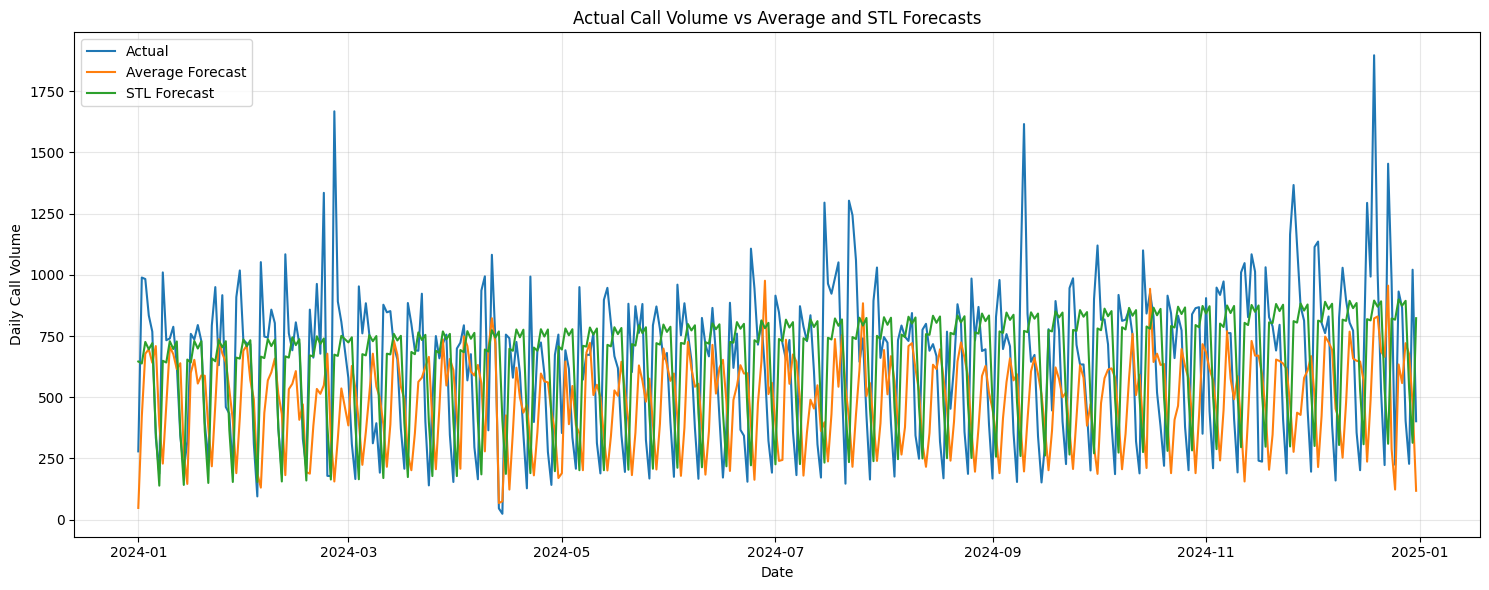

In [24]:
plt.figure(
    figsize=(15, 6)
)

plt.plot(
    daily["date"],
    daily["actual"],
    label="Actual"
)

plt.plot(
    daily["date"],
    daily["average_forecast"],
    label="Average Forecast"
)

plt.plot(
    daily["date"],
    daily["stl_forecast"],
    label="STL Forecast"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Daily Call Volume"
)

plt.title(
    "Actual Call Volume vs Average and STL Forecasts"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

## Comparison of Forecast Errors

The absolute forecasting errors are also compared over time.

A lower absolute error indicates that the forecast was closer to the actual call volume.

In [25]:
daily_error = (
    df.groupby("date")
      .agg({
          "abs_error_average": "mean",
          "abs_error_stl": "mean"
      })
      .reset_index()
)

daily_error["date"] = pd.to_datetime(
    daily_error["date"]
)

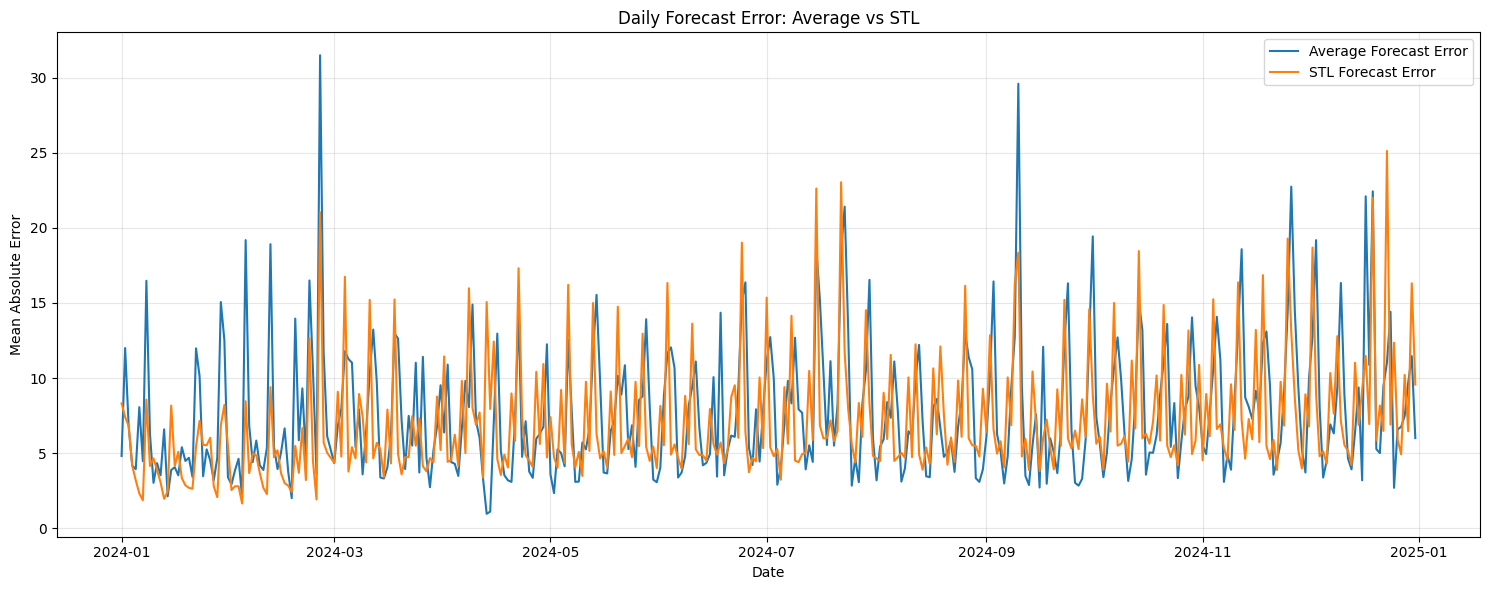

In [26]:
plt.figure(
    figsize=(15, 6)
)

plt.plot(
    daily_error["date"],
    daily_error["abs_error_average"],
    label="Average Forecast Error"
)

plt.plot(
    daily_error["date"],
    daily_error["abs_error_stl"],
    label="STL Forecast Error"
)

plt.xlabel("Date")

plt.ylabel(
    "Mean Absolute Error"
)

plt.title(
    "Daily Forecast Error: Average vs STL"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

## Export Results

The final accuracy measurements and interval-level comparison dataset are exported as CSV files so that the results can be retained and used for further analysis.

In [27]:
results.to_csv(
    "forecast_accuracy_results.csv",
    index=False
)

df.to_csv(
    "forecast_comparison_2024.csv",
    index=False
)

In [28]:
from google.colab import files

files.download(
    "forecast_accuracy_results.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
files.download(
    "forecast_comparison_2024.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

The forecasting accuracy of the Average forecasting method and STL forecasting method was evaluated using actual 2024 call-volume observations.

Forecast performance was assessed using MAE, RMSE, WAPE and forecast bias.

The STL method produced lower MAE, RMSE and WAPE values than the Average forecasting method, indicating better overall forecasting accuracy. Furthermore, the STL model produced a forecast bias closer to zero.

A Diebold-Mariano test was subsequently conducted to determine whether the difference in predictive accuracy was statistically significant.

The test produced a p-value below the 5% significance level. Therefore, the null hypothesis of equal predictive accuracy was rejected.

The results provide statistical evidence that the STL forecasting method produced more accurate forecasts than the Average forecasting method for the analyzed call-volume data.